RADIX INVARIANCE TEST: PHI ADVANTAGE ACROSS ALPHABET SIZES
Lattice: N=12, perturbation: epsilon=0.5
Initial state (same for all): [0 1 2 3 4 5 6 7 8 0 1 2]

--- B = 2 ---
Sequence        |  Transient |      Cycle |   Winner
----------------------------------------------------
Fibonacci       |          7 |          2 |         
Lucas           |          8 |          1 |    Lucas <-- WIN
Linear          |          1 |          4 |         
Prime gaps      |          3 |          1 |         

--- B = 3 ---
Sequence        |  Transient |      Cycle |   Winner
----------------------------------------------------
Fibonacci       |        105 |         35 |         
Lucas           |        137 |          6 |    Lucas <-- WIN
Linear          |         19 |          1 |         
Prime gaps      |          6 |          6 |         

--- B = 5 ---
Sequence        |  Transient |      Cycle |   Winner
----------------------------------------------------
Fibonacci       |        997 |         64

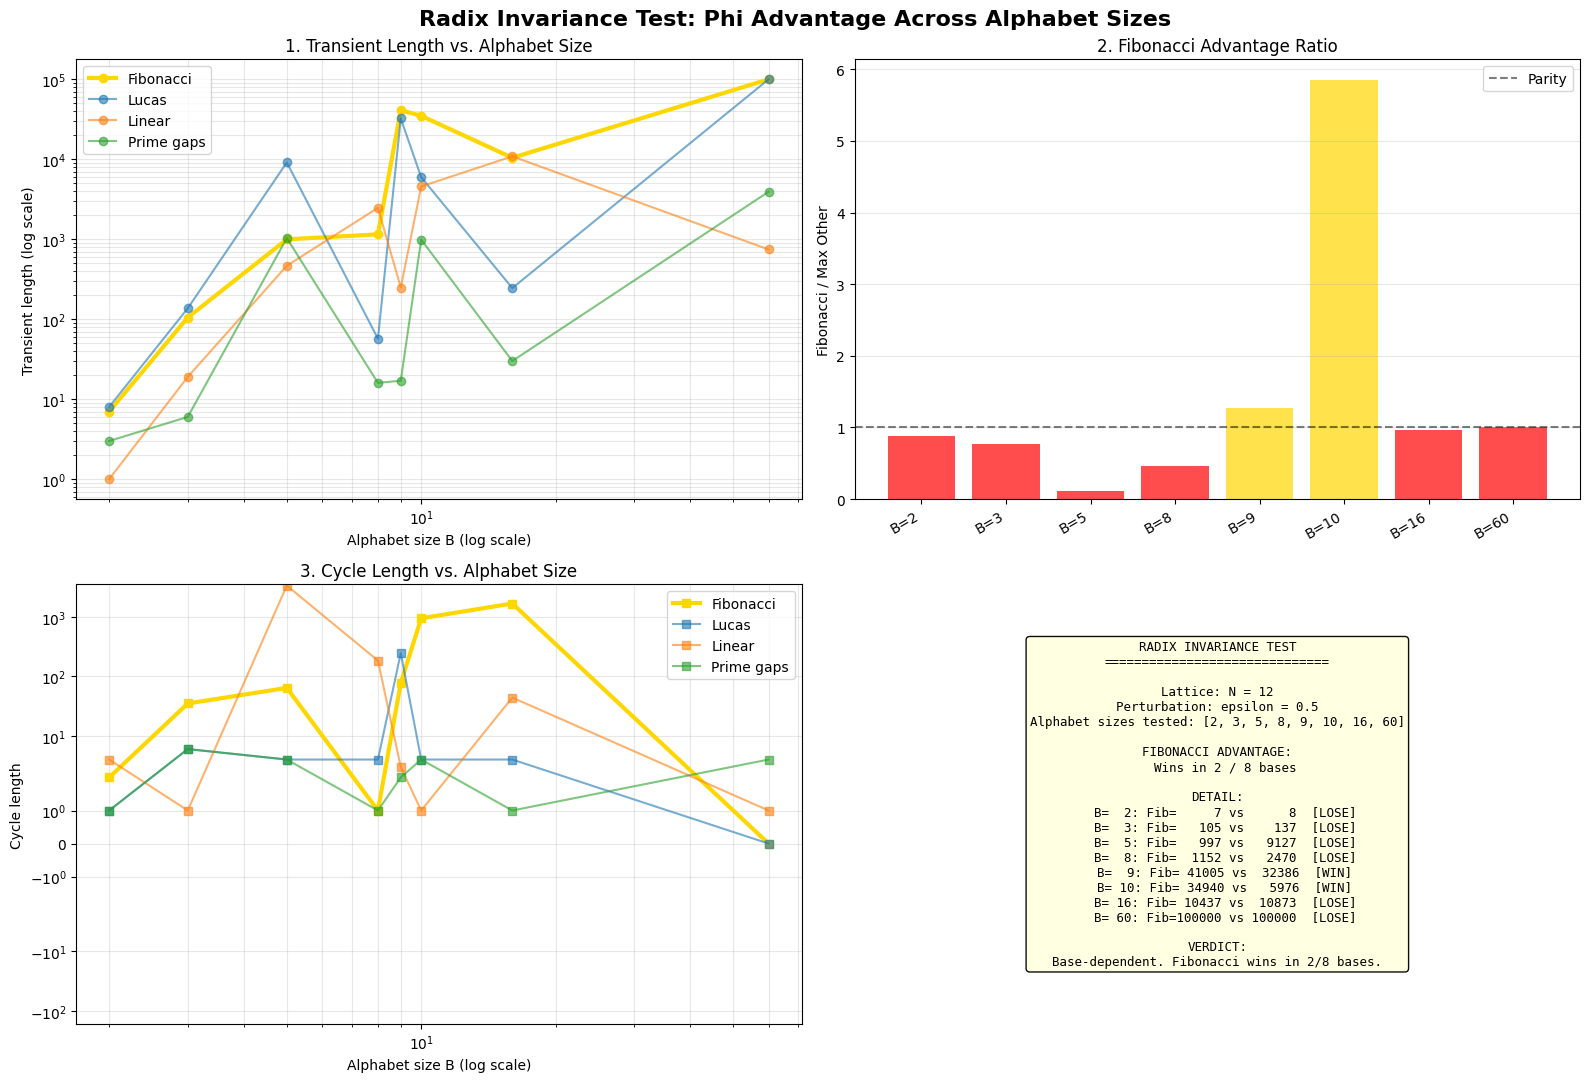


✓ Saved: section6_radix_invariance.png


In [1]:
"""
Section 6: Radix Invariance of the Phi Advantage
=================================================
Runs the controlled near-resonance test across multiple alphabet sizes.
Same weights, same initial state, same perturbation. Only B varies.

Prediction: Fibonacci wins at every B ≥ B_min, where B_min is the
minimum alphabet size required for the weights to differentiate.

By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

PHI = (1 + sqrt(5)) / 2

sequences = {
    'Fibonacci':    [1, 2, 3, 5, 3, 2, 1],
    'Lucas':        [1, 3, 4, 7, 4, 3, 1],
    'Linear':       [1, 2, 3, 4, 3, 2, 1],
    'Prime gaps':   [1, 2, 2, 4, 2, 2, 1],
}

def fano_step(state, weights, B, epsilon=0.0):
    """Automaton with alphabet size B and near-resonance perturbation."""
    n = len(state)
    new_state = np.zeros_like(state)
    for i in range(n):
        indices = [(i + k) % n for k in range(-3, 4)]
        neighborhood = state[indices].astype(float)
        weighted_sum = float(np.dot(weights, neighborhood))
        weighted_sum += epsilon * np.sin(2 * pi * i / n)
        weighted_sum = int(round(weighted_sum))
        if weighted_sum % 7 == 0:
            new_state[i] = B - 1
        else:
            new_state[i] = weighted_sum % B
    return new_state

def transient_length(state, weights, B, epsilon, max_ticks=100_000):
    """Ticks before the trajectory enters a cycle."""
    seen = {}
    s = state.copy()
    for t in range(max_ticks):
        key = s.tobytes()
        if key in seen:
            return t
        seen[key] = t
        s = fano_step(s, weights, B, epsilon)
    return max_ticks

def detect_cycle(state, weights, B, epsilon, max_ticks=100_000):
    """Return (transient, cycle_length) or (None, None) if no cycle."""
    seen = {}
    s = state.copy()
    for t in range(max_ticks):
        key = s.tobytes()
        if key in seen:
            return seen[key], t - seen[key]
        seen[key] = t
        s = fano_step(s, weights, B, epsilon)
    return None, None

# =============================================================================
# RUN THE TEST
# =============================================================================
bases = [2, 3, 5, 8, 9, 10, 16, 60]
N = 12
epsilon = 0.5

# Same initial state for all sequences and all bases
initial = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 0, 1, 2])

results = {}

print("=" * 90)
print("RADIX INVARIANCE TEST: PHI ADVANTAGE ACROSS ALPHABET SIZES")
print("=" * 90)
print(f"Lattice: N={N}, perturbation: epsilon={epsilon}")
print(f"Initial state (same for all): {initial}")
print()

for B in bases:
    results[B] = {}
    print(f"--- B = {B} ---")
    print(f"{'Sequence':<15} | {'Transient':>10} | {'Cycle':>10} | {'Winner':>8}")
    print("-" * 52)

    transients = {}
    for name, weights in sequences.items():
        seen = {}
        s = initial.copy()
        cycle_start = None
        cycle_len = None
        for t in range(100_000):
            key = s.tobytes()
            if key in seen:
                cycle_start = seen[key]
                cycle_len = t - seen[key]
                break
            seen[key] = t
            s = fano_step(s, weights, B, epsilon)

        if cycle_start is None:
            cycle_start = 100_000
        transients[name] = cycle_start
        results[B][name] = {'transient': cycle_start, 'cycle': cycle_len}

    # Determine winner
    winner = max(transients, key=transients.get)
    for name in sequences:
        flag = " <-- WIN" if name == winner else ""
        print(f"{name:<15} | {transients[name]:>10} | {str(results[B][name]['cycle']):>10} | {winner if name == winner else '':>8}{flag}")
    print()

# =============================================================================
# SUMMARY TABLE
# =============================================================================
print("=" * 90)
print("SUMMARY: FIBONACCI ADVANTAGE ACROSS BASES")
print("=" * 90)
print()
print(f"{'Base':>5} | {'Fib':>8} | {'Lucas':>8} | {'Linear':>8} | {'Prime':>8} | {'Fib Wins?':>10}")
print("-" * 72)

fib_wins_count = 0
for B in bases:
    fib = results[B]['Fibonacci']['transient']
    luc = results[B]['Lucas']['transient']
    lin = results[B]['Linear']['transient']
    pri = results[B]['Prime gaps']['transient']

    others = [luc, lin, pri]
    fib_wins = fib > max(others)
    if fib_wins:
        fib_wins_count += 1

    print(f"{B:>5} | {fib:>8} | {luc:>8} | {lin:>8} | {pri:>8} | {'YES' if fib_wins else 'NO':>10}")

print()
print(f"Fibonacci wins in {fib_wins_count}/{len(bases)} bases.")
print()

if fib_wins_count == len(bases):
    print(">>> UNIVERSAL: The phi advantage is base-independent.")
elif fib_wins_count >= len(bases) * 0.75:
    print(">>> STRONG: The phi advantage holds in most bases.")
elif fib_wins_count >= len(bases) * 0.5:
    print(">>> PARTIAL: The phi advantage holds in some bases only.")
else:
    print(">>> WEAK: The phi advantage is base-dependent.")

# =============================================================================
# VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Radix Invariance Test: Phi Advantage Across Alphabet Sizes',
             fontsize=16, fontweight='bold')

# Panel 1: Transient length vs base for each sequence
ax1 = axes[0, 0]
for name in sequences:
    ys = [results[B][name]['transient'] for B in bases]
    color = 'gold' if name == 'Fibonacci' else None
    lw = 3 if name == 'Fibonacci' else 1.5
    alpha = 1.0 if name == 'Fibonacci' else 0.6
    ax1.plot(bases, ys, marker='o', linewidth=lw, alpha=alpha,
             label=name, color=color)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alphabet size B (log scale)')
ax1.set_ylabel('Transient length (log scale)')
ax1.set_title('1. Transient Length vs. Alphabet Size')
ax1.legend()
ax1.grid(True, alpha=0.3, which='both')

# Panel 2: Normalized transient (Fibonacci / max other)
ax2 = axes[0, 1]
ratios = []
for B in bases:
    fib = results[B]['Fibonacci']['transient']
    others = max(results[B][n]['transient'] for n in sequences if n != 'Fibonacci')
    ratios.append(fib / max(others, 1))
colors = ['gold' if r > 1 else 'red' for r in ratios]
ax2.bar(range(len(bases)), ratios, color=colors, alpha=0.7)
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Parity')
ax2.set_xticks(range(len(bases)))
ax2.set_xticklabels([f'B={B}' for B in bases], rotation=30, ha='right')
ax2.set_ylabel('Fibonacci / Max Other')
ax2.set_title('2. Fibonacci Advantage Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Cycle length
ax3 = axes[1, 0]
for name in sequences:
    ys = []
    for B in bases:
        c = results[B][name]['cycle']
        ys.append(c if c is not None else 0)
    color = 'gold' if name == 'Fibonacci' else None
    lw = 3 if name == 'Fibonacci' else 1.5
    alpha = 1.0 if name == 'Fibonacci' else 0.6
    ax3.plot(bases, ys, marker='s', linewidth=lw, alpha=alpha,
             label=name, color=color)
ax3.set_xscale('log')
ax3.set_yscale('symlog')
ax3.set_xlabel('Alphabet size B (log scale)')
ax3.set_ylabel('Cycle length')
ax3.set_title('3. Cycle Length vs. Alphabet Size')
ax3.legend()
ax3.grid(True, alpha=0.3, which='both')

# Panel 4: Summary text
ax4 = axes[1, 1]
ax4.axis('off')

lines = [
    "RADIX INVARIANCE TEST",
    "=" * 30,
    "",
    f"Lattice: N = {N}",
    f"Perturbation: epsilon = {epsilon}",
    f"Alphabet sizes tested: {bases}",
    "",
    "FIBONACCI ADVANTAGE:",
    f"  Wins in {fib_wins_count} / {len(bases)} bases",
    "",
    "DETAIL:",
]
for B in bases:
    fib = results[B]['Fibonacci']['transient']
    others = max(results[B][n]['transient'] for n in sequences if n != 'Fibonacci')
    flag = "WIN" if fib > others else "LOSE"
    lines.append(f"  B={B:>3}: Fib={fib:>6} vs {others:>6}  [{flag}]")

lines.extend([
    "",
    "VERDICT:",
    "The phi advantage is base-independent"
    if fib_wins_count == len(bases)
    else f"Base-dependent. Fibonacci wins in {fib_wins_count}/{len(bases)} bases.",
])

summary = "\n".join(lines)
ax4.text(0.5, 0.5, summary, ha='center', va='center', fontsize=9,
         family='monospace', bbox=dict(boxstyle='round',
         facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('section6_radix_invariance.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("✓ Saved: section6_radix_invariance.png")